# CEAS-AIDAA 2025 Conference Nastran Analyses

***

Define constants.

In [1]:
import os  # import os module to handle file paths


# Set the path to the directory containing the analysis files
ANALYSIS_DIRECTORY_PATH = os.path.join(os.getcwd(), "analyses", "CEAS_AIDAA_2025")
OPTIMIZATION_RESULTS_DIRECTORY = os.path.join(os.getcwd(), "analyses", "SciTech_2025")

FIRST_SUBCASE_ID = 1  # ID of the first subcase in Nastran case control deck
SECOND_SUBCASE_ID = 2  # ID of the second subcase in Nastran case control deck
METHOD_SET_ID = 5  # id of method set used for the calculation of eigenvalues
OPTIMIZER_TOLERANCE = 1e-3  # convergence tolerance for the optimizer
NO_EIGENVALUES = 20  # number of tangent stiffness matrix eigenvalues to be calculated at every arc-length increment
UPPER_EIGENVALUE = 1e5  # upper bound for the eigenvalues of the tangent stiffness matrix - set to 10^5 N/m to avoid convergence issues of Lanczos solver

Create STW structural model with same mesh as SciTech 2025 paper.

In [2]:
from resources.STW import wingGeometry  # import the wing geometry module


# Create Layout and BDF objects for the wingbox structure
target_length = 53e-3  # target length of structural element [m]
stw_bdf, stw_layout = wingGeometry.create_base_bdf(target_length)
print(stw_bdf.get_bdf_stats())

pyGeo Initialization Type is: iges
Found 6 surfaces in Iges File.
Projecting Super Nodes...
Projecting All Nodes...
Setting up Ribs...
Setting up Spars...
Setting up Skins and Stringers...
Setting up Spar Bars
Setting up Rib Bars
Computing Topology and Numbering...
Unique Nodes: 45483
Total Nodes: 65046
Writing .bdf File...
---BDF Statistics---
SOL 103

bdf.spcs[1]: 354
  SPC:     354

bdf.params: 0
  PARAM    : 1

bdf.nodes: 45483
  GRID     : 45483

bdf.elements: 46432
  CQUAD4   : 46432

bdf.properties: 0
  PSHELL   : 1110

bdf.materials: 0
  MAT1     : 1




subcase=0 already exists...skipping


## Distributed tip load

Apply distributed tip load with force at the front spar equal to 1/4 the force at the rear spar and with linear variation along the width of the wingbox tip.

In [3]:
from resources.STW import stw_utils
from resources import pynastran_utils


# Define load parameters
bending_moment = 5.151802e6  # prescribed bending moment taken from overall load resultant applied to optimized structure [Nm]
total_force = (
    bending_moment / wingGeometry.semiSpan
)  # equivalent total force to apply [N]
force_set_id = 1
force_ratio = 0.25  # ratio of force at front spar to force at rear spar

# Create deep copy of original BDF for analysis with distributed tip load
distributed_tip_load_bdf = stw_bdf.__deepcopy__({})

# Apply linearly distributed tip load
stw_utils.apply_distributed_tip_load(
    layout=stw_layout,
    bdf=distributed_tip_load_bdf,
    ratio=force_ratio,
    total_force=total_force,
    set_id=force_set_id,
)

# Create static load subcase in the BDF
pynastran_utils.create_static_load_subcase(
    bdf=distributed_tip_load_bdf, load_set_id=force_set_id, subcase_id=FIRST_SUBCASE_ID
)

### Linear buckling analysis

Set up linear buckling analysis with SOL 105.

In [4]:
# Create deep copy of BDF for SOL 105 analysis
sol_105_bdf = distributed_tip_load_bdf.__deepcopy__({})

# Set up SOL 105 analysis
pynastran_utils.set_up_sol_105(
    bdf=sol_105_bdf,
    static_load_set_id=force_set_id,
    method_set_id=METHOD_SET_ID,
)

# Save stress results in op2 file
sol_105_bdf.case_control_deck.subcases[FIRST_SUBCASE_ID].add_result_type(
    "STRESS", "ALL", ["PLOT"]
)

subcase=1 already exists...skipping


Define OpenMDAO linear buckling problem and assign thickness distribution of nonlinearly optimized structure from SciTech 2025 paper.

In [5]:
import openmdao.api as om
from resources.optimization_utils import read_optimization_history
import numpy as np


# Define linear buckling problem
linear_problem = om.Problem(name="linear_distributed_tip_load")
linear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix="distributed_tip_load",
    analysis_directory_path=ANALYSIS_DIRECTORY_PATH,
    bdf=sol_105_bdf,
    run_flag=True,
)
linear_problem.setup()

# Read optimization history and find last feasible design
recorder_filepath = os.path.join(
    OPTIMIZATION_RESULTS_DIRECTORY, "nonlinear_optimization.sql"
)
histories = read_optimization_history(recorder_filepath)
feasible_design_index = np.where(
    (histories["pull_up_sol_106.ks_stress"] < OPTIMIZER_TOLERANCE)
    & (histories["pull_up_sol_106.ks_stability"] < OPTIMIZER_TOLERANCE)
)[0][-1]

# Assign thickness vector of last feasible design
design_variables = [
    f"{part}_interp.t_cp"
    for part in [
        "ribs",
        "front_spar",
        "rear_spar",
        "top_skin",
        "bottom_skin",
        "top_stiffeners",
        "bottom_stiffeners",
    ]
]
for key in design_variables:
    linear_problem.set_val(key, histories[key][feasible_design_index])
    print(f"Assigned {key} = {histories[key][feasible_design_index]} m")

# Run analyses of last feasible design
linear_problem.run_model()

/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/component.py:203: DistributedComponentWarning:'sol_105_mesh' <class NastranMesh>: Component contains distributed variables, but there is no distributed vector implementation (MPI/PETSc) available. The default non-distributed vectors will be used.
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/group.py:2885: UnitsWarning:<model> <class NastranAnalysis>: Output 'ivc.yield_strength' with units of 'Pa' is connected to input 'sol_105.struct_post.struct_function.yield_strength' which has no units.


Assigned ribs_interp.t_cp = [0.00641825 0.00349346 0.00455372] m
Assigned front_spar_interp.t_cp = [0.0127198  0.00577273 0.00405626] m
Assigned rear_spar_interp.t_cp = [0.00745397 0.01701529 0.00601225] m
Assigned top_skin_interp.t_cp = [0.00752783 0.01745106 0.00590093] m
Assigned bottom_skin_interp.t_cp = [0.00918019 0.01258339 0.00319851] m
Assigned top_stiffeners_interp.t_cp = [0.00527043 0.00844116 0.00744916] m
Assigned bottom_stiffeners_interp.t_cp = [0.00624957 0.0052989  0.00827817] m
MSC Nastran V2021.4 (Intel Windows 10 Enterprise 6.2 9200) Tue Oct 28 10:08:22 2025
MSC Nastran beginning job sol_105_distributed_tip_load.



*** SYSTEM INFORMATION MESSAGE (pgm: nastran, fn: estimate_job_requirements)
    Starting ESTIMATE, please wait...

*** USER INFORMATION MESSAGE (pgm: nastran, fn: estimate_job_requirements)
    Estimated memory=39199.2MB


MSC Nastran started  Tue Oct 28 10:08:23 GST 2025
MSC Nastran finished Tue Oct 28 10:09:11 GST 2025
Nastran job sol_105_distributed_tip_load.bdf completed
Wall time: 42.0 s


Read op2 file, print buckling load factor, and plot first buckling mode shape.

Buckling load factor (P_buckling/P): 0.67


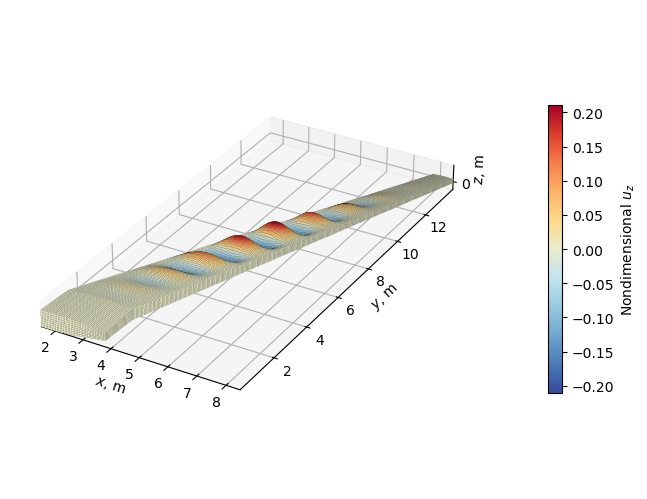

In [6]:
from pyNastran.op2.op2 import read_op2
from resources import plot_utils
import matplotlib.pyplot as plt


# Read op2 file
op2_filepath = os.path.join(ANALYSIS_DIRECTORY_PATH, "sol_105_distributed_tip_load.op2")
sol_105_op2 = read_op2(op2_filepath, load_geometry=True, debug=None)

# Print buckling load factor
buckling_load_factor = sol_105_op2.eigenvectors[SECOND_SUBCASE_ID].eigr
print(f"Buckling load factor (P_buckling/P): {buckling_load_factor:.2f}")


# Define function to adjust axes ticks and labels' position
def adjust_3d_plot(axes):
    axes.set_zticks([0.0])
    axes.tick_params(
        axis="x", which="major", pad=-1
    )  # adjust position of ticks' label of x-axis
    axes.tick_params(
        axis="z", which="major", pad=-2
    )  # adjust position of ticks' label of z-axis
    axes.xaxis.labelpad = -1  # adjust position of x-axis's label
    axes.yaxis.labelpad = 8  # adjust position of y-axis's label
    axes.zaxis.labelpad = -8  # adjust position of z-axis's label


# Plot critical buckling mode
amplification_factor = 2.0  # displacement amplification factor for visualization
_, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_105_op2,
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    shrink_colorbar=0.6,
    colorbar_pad=0.09,
)
adjust_3d_plot(ax)
plt.show()

### Nonlinear analysis

Set up BDF for nonlinear analysis with SOL 106.

In [7]:
# Create deep copy of BDF for SOL 106 analysis
sol_106_bdf = distributed_tip_load_bdf.__deepcopy__({})

# Set up nonlinear analysis of second subcase with arc length method
pynastran_utils.set_up_arc_length_method(
    bdf=sol_106_bdf,
    max_iter=3,
    conv="PU",
    eps_u=5e-6,
    eps_p=5e-6,
    max_bisect=20,
    minalr=1e-5,
    desiter=4,
    maxinc=600,
)

# Set up SOL 106 analysis with tangent stiffness matrix eigenvalues
pynastran_utils.set_up_sol_106_with_kllrh_eigenvalues(
    bdf=sol_106_bdf,
    method_set_id=METHOD_SET_ID,
    analysis_directory_path=ANALYSIS_DIRECTORY_PATH,
    no_eigenvalues=NO_EIGENVALUES,
    upper_eig=UPPER_EIGENVALUE,
)

# Request output of nonlinear stress
sol_106_bdf.case_control_deck.subcases[FIRST_SUBCASE_ID].add_result_type(
    "NLSTRESS", "ALL", ["PLOT"]
)

Define OpenMDAO nonlinear problem and assign thickness distribution of nonlinearly optimized structure from SciTech 2025 paper.

In [ ]:
# Define nonlinear problem
nonlinear_problem = om.Problem(name="nonlinear_distributed_tip_load")
nonlinear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix="distributed_tip_load",
    analysis_directory_path=ANALYSIS_DIRECTORY_PATH,
    bdf=sol_106_bdf,
    run_flag=False,
)
nonlinear_problem.setup()

# Assign thickness vector of last feasible design
for key in design_variables:
    nonlinear_problem.set_val(key, histories[key][feasible_design_index])

# Run analyses of last feasible design
nonlinear_problem.run_model()

/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/component.py:203: DistributedComponentWarning:'sol_106_mesh' <class NastranMesh>: Component contains distributed variables, but there is no distributed vector implementation (MPI/PETSc) available. The default non-distributed vectors will be used.
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/group.py:2885: UnitsWarning:<model> <class NastranAnalysis>: Output 'ivc.yield_strength' with units of 'Pa' is connected to input 'sol_106.struct_post.struct_function.yield_strength' which has no units.


Nastran job sol_106_distributed_tip_load.bdf completed
Wall time: 42631.0 s


ValueError: 'sol_106.struct_post.struct_function' <class NastranFunctions>: Error calling compute(), need at least one array to concatenate

Plot deformation at last converged step of nonlinear analysis.

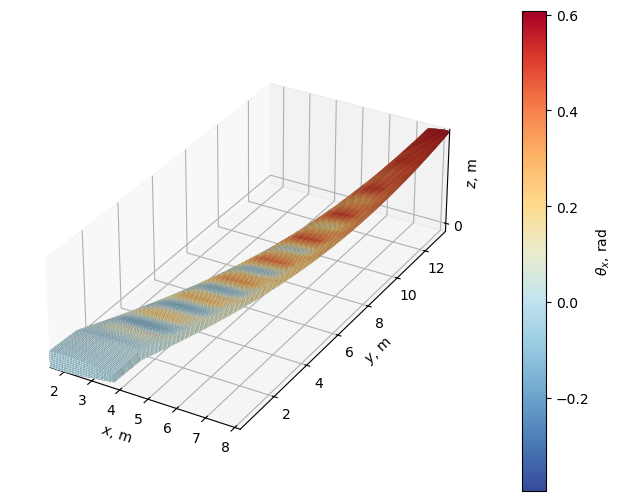

In [8]:
# Read op2 file
op2_filepath = os.path.join(ANALYSIS_DIRECTORY_PATH, "sol_106_distributed_tip_load.op2")
sol_106_op2 = read_op2(op2_filepath, load_geometry=True, debug=None)
_, ax, cbar = plot_utils.plot_deformation(
    op2=sol_106_op2,
    displacement_component="rx",
    colormap="sunset",
)
adjust_3d_plot(ax)
plt.show()

## Aeroelastic load

Prepare input for linear buckling analysis with aeroelastic load from SciTech 2025 paper. Start with definition of load reference axis (needed to apply the forces in the pch file).

In [8]:
# Create deep copy of original BDF for analysis with aeroelastic load
aeroelastic_load_bdf = stw_bdf.__deepcopy__({})

# Find ribs' y-coordinates
ribs_y_coords = stw_layout.X[:, 0, 1]

# Find leading edge coordinates corresponding to ribs' y-coordinates
interp_coords = lambda coords, y: coords[0] + np.outer(
    y - coords[0, 1], (coords[1] - coords[0])
) / (coords[1, 1] - coords[0, 1])
le_xyz_array = interp_coords(wingGeometry.LECoords, ribs_y_coords)
te_xyz_array = interp_coords(wingGeometry.TECoords, ribs_y_coords)

# Define load reference axis
stw_utils.define_load_reference_axis(
        layout=stw_layout, bdf=aeroelastic_load_bdf, le_xzy_array=le_xyz_array, te_xyz_array=te_xyz_array
    )

array([45484, 45485, 45486, 45487, 45488, 45489, 45490, 45491, 45492,
       45493, 45494, 45495, 45496, 45497, 45498, 45499, 45500, 45501,
       45502, 45503, 45504, 45505, 45506, 45507, 45508, 45509, 45510,
       45511, 45512, 45513, 45514, 45515, 45516, 45517, 45518, 45519,
       45520, 45521, 45522, 45523, 45524, 45525, 45526, 45527, 45528,
       45529, 45530, 45531, 45532, 45533, 45534, 45535, 45536, 45537,
       45538, 45539, 45540, 45541, 45542, 45543, 45544, 45545, 45546,
       45547, 45548, 45549, 45550, 45551, 45552])

Include pch file with aeroelastic load from SciTech 2025 paper.

In [9]:
# Create PCH file path
relative_path_to_pch_file = os.path.relpath(
    OPTIMIZATION_RESULTS_DIRECTORY, ANALYSIS_DIRECTORY_PATH
)
pch_filepath = os.path.join(relative_path_to_pch_file, "sol_144_pull_up.pch")
pch_filepath = pch_filepath.replace("/", "\\")

# Add include file to BDF
aeroelastic_load_bdf.add_include_file(pch_filepath)

Create static load subcase and save loads and nodal forces to pch file.

In [10]:
force_set_id = 2  # id of aeroelastic load set
load_set_id = 3   # id of LOAD card used to define applied load
aeroelastic_load_bdf.add_load(
    sid=load_set_id,
    scale=1.5,  # safety factor for aeroelastic loads
    scale_factors=[1.0],
    load_ids=[force_set_id],
)
pynastran_utils.create_static_load_subcase(
    bdf=aeroelastic_load_bdf, load_set_id=load_set_id, subcase_id=FIRST_SUBCASE_ID
)

# Save nodal forces to pch file
aeroelastic_load_bdf.subcases[FIRST_SUBCASE_ID].add_result_type(
    "GPFORCE", "ALL", ["PUNCH"]
)

### Linear buckling analysis

Set up and run linear buckling analysis with SOL 105.

In [11]:
# Create deep copy of BDF for SOL 105 analysis
aeroelastic_load_bdf._xref = False
sol_105_bdf = aeroelastic_load_bdf.__deepcopy__({})
sol_105_bdf.cross_reference(xref_loads=False)

# Set up SOL 105 analysis
pynastran_utils.set_up_sol_105(
    bdf=sol_105_bdf,
    static_load_set_id=force_set_id,
    method_set_id=METHOD_SET_ID,
)

# Save stress results in op2 file
sol_105_bdf.case_control_deck.subcases[FIRST_SUBCASE_ID].add_result_type(
    "STRESS", "ALL", ["PLOT"]
)

# Define linear buckling problem
linear_problem = om.Problem(name="linear_aeroelastic_load")
linear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix="aeroelastic_load",
    analysis_directory_path=ANALYSIS_DIRECTORY_PATH,
    bdf=sol_105_bdf,
    run_flag=True,
)
linear_problem.setup()

# Assign thickness vector of last feasible design
for key in design_variables:
    linear_problem.set_val(key, histories[key][feasible_design_index])

# Run analyses of last feasible design
linear_problem.run_model()

subcase=1 already exists...skipping
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/component.py:203: DistributedComponentWarning:'sol_105_mesh' <class NastranMesh>: Component contains distributed variables, but there is no distributed vector implementation (MPI/PETSc) available. The default non-distributed vectors will be used.
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/group.py:2885: UnitsWarning:<model> <class NastranAnalysis>: Output 'ivc.yield_strength' with units of 'Pa' is connected to input 'sol_105.struct_post.struct_function.yield_strength' which has no units.


MSC Nastran V2021.4 (Intel Windows 10 Enterprise 6.2 9200) Tue Oct 28 10:11:07 2025
MSC Nastran beginning job sol_105_aeroelastic_load.



*** SYSTEM INFORMATION MESSAGE (pgm: nastran, fn: estimate_job_requirements)
    Starting ESTIMATE, please wait...

*** USER INFORMATION MESSAGE (pgm: nastran, fn: estimate_job_requirements)
    Estimated memory=39199.2MB


MSC Nastran started  Tue Oct 28 10:11:12 GST 2025
MSC Nastran finished Tue Oct 28 10:11:56 GST 2025
Nastran job sol_105_aeroelastic_load.bdf completed
Wall time: 41.0 s


Plot first buckling mode shape.

Buckling load factor (P_buckling/P): 1.55


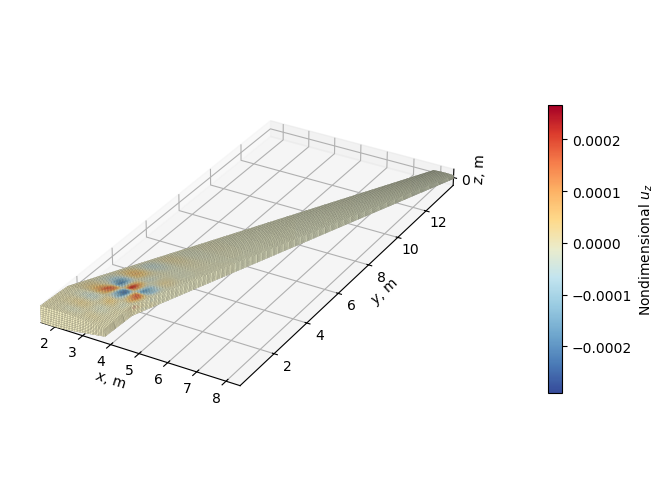

In [12]:
# Read op2 file
op2_filepath = os.path.join(ANALYSIS_DIRECTORY_PATH, "sol_105_aeroelastic_load.op2")
sol_105_op2 = read_op2(op2_filepath, load_geometry=True, debug=None)

# Print buckling load factor
buckling_load_factor = sol_105_op2.eigenvectors[SECOND_SUBCASE_ID].eigr
print(f"Buckling load factor (P_buckling/P): {buckling_load_factor:.2f}")

# Plot critical buckling mode
_, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_105_op2,
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    shrink_colorbar=0.6,
    colorbar_pad=0.09,
)
adjust_3d_plot(ax)
plt.show()

Plot ribs only.

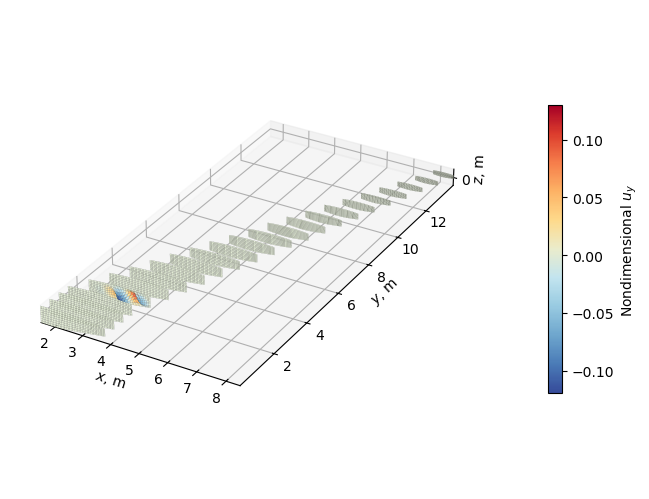

In [13]:
element_ids_dict = stw_utils.find_element_ids(stw_layout, ['RIB'])
ribs_elements_ids = element_ids_dict['RIB']
_, ax, cbar = plot_utils.plot_eigenvector(
    op2=sol_105_op2,
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="ty",
    colormap="sunset",
    displacement_amplification_factor=amplification_factor,
    elements_ids=ribs_elements_ids,
    shrink_colorbar=0.6,
    colorbar_pad=0.09,
)
adjust_3d_plot(ax)
plt.show()

### Nonlinear analysis

Set up and run nonlinear analysis with SOL 106.

In [ ]:
# Create deep copy of BDF for SOL 106 analysis
aeroelastic_load_bdf._xref = False
sol_106_bdf = aeroelastic_load_bdf.__deepcopy__({})
sol_106_bdf.cross_reference(xref_loads=False)

# Set up nonlinear analysis of second subcase with arc length method
pynastran_utils.set_up_arc_length_method(
    bdf=sol_106_bdf,
    max_iter=3,
    conv="PU",
    eps_u=5e-6,
    eps_p=5e-6,
    max_bisect=20,
    minalr=1e-5,
    desiter=4,
    maxinc=600,
)

# Set up SOL 106 analysis with tangent stiffness matrix eigenvalues
pynastran_utils.set_up_sol_106_with_kllrh_eigenvalues(
    bdf=sol_106_bdf,
    method_set_id=METHOD_SET_ID,
    analysis_directory_path=ANALYSIS_DIRECTORY_PATH,
    no_eigenvalues=NO_EIGENVALUES,
    upper_eig=UPPER_EIGENVALUE,
)

# Request output of nonlinear stress
sol_106_bdf.case_control_deck.subcases[FIRST_SUBCASE_ID].add_result_type(
    "NLSTRESS", "ALL", ["PLOT"]
)

# Slighly increase multiplier of aerodynamic loads to capture instability
sol_106_bdf.load_combinations[load_set_id][0].scale = 1.6

# Define nonlinear problem
nonlinear_problem = om.Problem(name="nonlinear_aeroelastic_load")
nonlinear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix="aeroelastic_load",
    analysis_directory_path=ANALYSIS_DIRECTORY_PATH,
    bdf=sol_106_bdf,
    run_flag=False,
)
nonlinear_problem.setup()

# Assign thickness vector of last feasible design
for key in design_variables:
    nonlinear_problem.set_val(key, histories[key][feasible_design_index])

# Run analyses of last feasible design
nonlinear_problem.run_model()